[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Biswajit1999/daily-astro-notebooks/blob/master/sdss/2026-07-30-qso-vs-galaxy-colors/notebook.ipynb)

# Can you tell quasars from galaxies just by their colors?

Before you even take a spectrum, SDSS's photometric survey measures brightness in five filters (u, g, r, i, z, from ultraviolet to near-infrared). Quasars tend to look bluer than typical galaxies at the same brightness because a lot of their light comes from a hot accretion disk rather than starlight. I wanted to check whether a simple color-color plot actually separates the two populations using real SDSS photometry matched to spectroscopically confirmed classes.

In [1]:
from astroquery.sdss import SDSS
import numpy as np
import matplotlib.pyplot as plt

query = '''
SELECT TOP 1500 p.u, p.g, p.r, p.i, s.class
FROM PhotoObj AS p
JOIN specObj AS s ON p.objid = s.bestobjid
WHERE (s.class = 'QSO' OR s.class = 'GALAXY') AND p.u BETWEEN 15 AND 22 AND p.g BETWEEN 15 AND 22
'''
tab = SDSS.query_sql(query)
print(len(tab), 'objects retrieved')
print(tab[:5])

1500 objects retrieved
   u        g        r        i     class 
-------- -------- -------- -------- ------
19.00659 17.46996 16.69207 16.29661 GALAXY
20.55509  18.5024 17.25141 16.77685 GALAXY
18.73435 16.83528 15.89845 15.49562 GALAXY
19.27567 17.23888 16.27929 15.86932 GALAXY
19.88979 18.18502 17.38777 17.00101 GALAXY


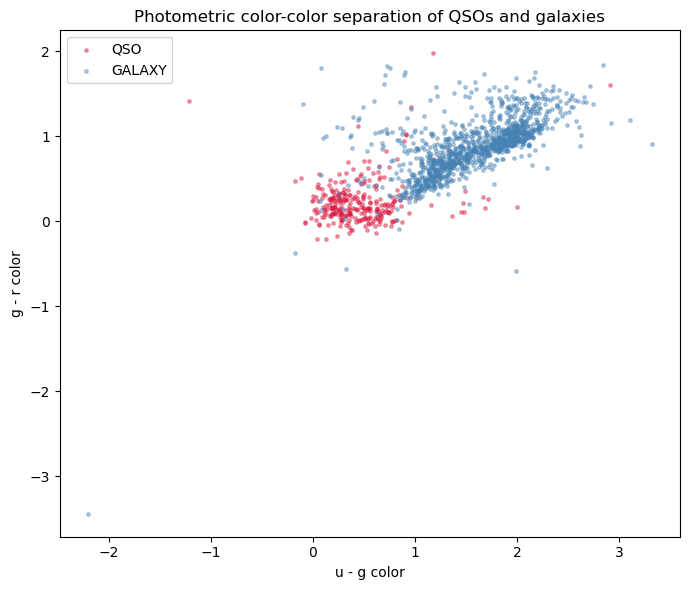

In [2]:
u = np.array(tab['u']); g = np.array(tab['g']); r = np.array(tab['r']); i = np.array(tab['i'])
cls = np.array(tab['class'])
ug = u - g
gr = g - r

plt.figure(figsize=(7,6))
for label, color in [('QSO', 'crimson'), ('GALAXY', 'steelblue')]:
    mask = cls == label
    plt.scatter(ug[mask], gr[mask], s=6, alpha=0.4, label=label, color=color)
plt.xlabel('u - g color')
plt.ylabel('g - r color')
plt.legend()
plt.title('Photometric color-color separation of QSOs and galaxies')
plt.tight_layout()
plt.savefig('color_color.png', dpi=120)
plt.show()

The two populations do separate reasonably well -- quasars cluster toward bluer u-g colors while galaxies spread toward redder colors, though there's real overlap in the middle. This is exactly why SDSS (and other surveys) use color cuts as a first-pass, cheap way to pick quasar candidates for follow-up spectroscopy, saving the expensive spectra for the objects most likely to be interesting.

**What I'd look at next:** Add the i-band and a redshift cut, since quasar colors shift as redshift moves different emission lines in and out of the filters (this is the classic quasar 'redshift desert' problem in color selection).

**Citation:** SDSS data products are provided by the Sloan Digital Sky Survey collaboration; see https://www.sdss.org/collaboration/citing-sdss/.